In [2]:
require(data.table)
require(tidyverse)
require(dada2)
require(phyloseq)
require(genefilter)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)
options(repr.plot.width=20, repr.plot.height=15)

Loading required package: dada2

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘dada2’”


In [5]:
#load sample metadata skipping first row
#load tracker for reads
track=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run2_Seqnums_16S.csv")
#load sample metadata
samdt=fread("/home/caroline_desouza_uml_edu/2_randomized_immune_metagenomics_PCR.csv", header=TRUE)
#load csv files after removing chimeras
asv_all=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run2_16S_ASV_nochim.csv")
taxa=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run2_16S_taxa.csv", header=TRUE, row.names=1)

## condition 

In [48]:
condition <- condition[, c("V1", "MonthYear", "colony", "Health_Status", "Date_ITS2") := NULL]
head(condition)

Tubelabel_species,Condition
<chr>,<chr>
052022_BEL_CBC_T1_2_SSID,Diseased
052022_BEL_CBC_T2_9_PAST,Healthy
052022_BEL_CBC_T2_1_SSID,Healthy
052022_BEL_CBC_T2_71_OFAV,Healthy
052022_BEL_CBC_T3_8_PAST,Healthy
052022_BEL_CBC_T3_13_MCAV,Healthy


In [49]:
#add conditions from pcr=read.csv(file="/home/caroline_desouza_uml_edu/pcr_meta.csv", header=TRUE, row.names=1)
samdt <- merge(samdt, condition, by = "Tubelabel_species", all = FALSE)
head(samdt)

Tubelabel_species,V1,Health_Status,Date_Extracted,Raw_ng_ul,Extraction_physical_location,Date_Enriched,Microbe_Location,colony,Date_16S,Date_ITS2,16S double band,V13,Condition
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
012024_BEL_CBC_T1_557_SSID,50,Healthy,2_17_2025,44.6,UML_NARWHAL_R2_B16,,,1_3,3_4_2025,7_7_2025,y,,Healthy
012024_BEL_CBC_T1_563_PSTR,58,Healthy,2_17_2025,35.8,UML_NARWHAL_R2_B16,,,1_12,3_6_2025,7_7_2025,,,Healthy
012024_BEL_CBC_T2_601_OFAV,48,Healthy,2_17_2025,89,UML_NARWHAL_R2_B16,,,2_79,3_4_2025,7_7_2025,,,Healthy
012024_BEL_CBC_T2_605_SSID,89,Healthy,2_17_2025,59.8,UML_NARWHAL_R2_B16,,,2_99,3_10_2025,7_10_2025,y,,CLB
012024_BEL_CBC_T3_627_PAST,81,Healthy,2_20_2025,10.5,UML_NARWHAL_R2_B16,,,3_34,3_10_2025,7_10_2025,y,,Healthy
012024_BEL_CBC_T3_631_MCAV,49,Healthy,2_20_2025,77.6,UML_NARWHAL_R2_B16,,,3_21,3_4_2025,7_7_2025,,,Healthy


## organize sample data, no longer using condition

In [6]:
#cleaning samdt 
samdt <- samdt[samdt$Date_16S != 'NA', ]
# Create a new data frame with the species, date, and transect columns
# Example samdt (make sure your data is a data.table)
setDT(samdt)
# Split Tubelabel_species by "_" and assign new columns
samdt[, c("date_sampled", "transect", "species") := {
  parts <- strsplit(Tubelabel_species, "_")
  list(
    sapply(parts, `[`, 1),  # date is first element
    sapply(parts, `[`, 4),  # transect is 4th element
    sapply(parts, `[`, 6)   # species is 6th element
  )
}]

In [7]:
# Rename a date to date sampled
sample_date <- setnames(samdt, "date", "date_sampled", skip_absent=TRUE)
#changing format of date_sampled to be Jan 2024
sample_date$date_sampled <- as.factor(sample_date$date_sampled)
# Convert to Date format 
sample_date$DateFormatted <- as.Date(paste0(sample_date$date_sampled, "01"), format = "%m%Y%d")
# now will have a new column that has Month Year instead of date_sampled
sample_date$MonthYear <- format(sample_date$DateFormatted, "%b %Y")
sample_date$MonthYear <- factor(sample_date$MonthYear, levels = unique(sample_date$MonthYear))

#MonthYear in chronological order
head(sample_date)

V1,Tubelabel_species,Health_Status,Date_Extracted,Raw_ng_ul,Extraction_physical_location,Date_Enriched,Microbe_Location,colony,Date_16S,Date_ITS2,16S double band,V13,date_sampled,transect,species,DateFormatted,MonthYear
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<chr>,<date>,<fct>
1,052022_BEL_CBC_T1_2_SSID,Healthy,12_2_2024,7.73,"UML_NARWHAL_R2_B14, UML_NARWHAL_R2_B33",,,1_3,1_22_2025,6_26_2025,,,052022,T1,SSID,2022-05-01,May 2022
2,092023_BEL_CBC_T1_175_PAST,Healthy,1_15_2025,2.3,UML_NARWHAL_R2_B15,,,1_13,1_22_2025,6_26_2025,y,,092023,T1,PAST,2023-09-01,Sep 2023
4,022024_BEL_CBC_T3_851_PSTR,Healthy,11_26_2024,64.2,UML_NARWHAL_R2_B13,,,3_70,1_23_2025,6_26_2025,,,022024,T3,PSTR,2024-02-01,Feb 2024
5,082024_BEL_CBC_T4_1609_OFAV,Healthy,1_15_2025,61.2,UML_NARWHAL_R2_B15,,,4_78,1_23_2025,6_26_2025,y,,082024,T4,OFAV,2024-08-01,Aug 2024
6,122023_BEL_CBC_T3_526_SSID,Healthy,11_19_2024,16.4,UML_NARWHAL_R2_B13,,,3_5,1_23_2025,6_26_2025,,,122023,T3,SSID,2023-12-01,Dec 2023
7,112023_BEL_CBC_T4_399_MCAV,Healthy,11_15_2024,13.9,UML_NARWHAL_R2_B12,,,4_76,1_23_2025,6_26_2025,,,112023,T4,MCAV,2023-11-01,Nov 2023


In [9]:
 #cleaning up sample_norm to only be metadata
samdt<- sample_date[, c("Tubelabel_species", "Health_Status", "colony", "Date_16S", "transect", "species", "MonthYear")]
head(samdt)

Tubelabel_species,Health_Status,colony,Date_16S,transect,species,MonthYear
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
052022_BEL_CBC_T1_2_SSID,Healthy,1_3,1_22_2025,T1,SSID,May 2022
092023_BEL_CBC_T1_175_PAST,Healthy,1_13,1_22_2025,T1,PAST,Sep 2023
022024_BEL_CBC_T3_851_PSTR,Healthy,3_70,1_23_2025,T3,PSTR,Feb 2024
082024_BEL_CBC_T4_1609_OFAV,Healthy,4_78,1_23_2025,T4,OFAV,Aug 2024
122023_BEL_CBC_T3_526_SSID,Healthy,3_5,1_23_2025,T3,SSID,Dec 2023
112023_BEL_CBC_T4_399_MCAV,Healthy,4_76,1_23_2025,T4,MCAV,Nov 2023


## filtering samples with less than 10K reads

In [10]:
#cleaning track of samples with less than 10K reads
clean_track <- track[track$nonchim > 10000, ]
setnames(clean_track, c("V1"), c("Tubelabel_species"), skip_absent=TRUE)
head(clean_track)

Tubelabel_species,input,filtered,denoisedF,denoisedR,merged,nonchim
<chr>,<int>,<int>,<int>,<int>,<int>,<int>
012024-BEL-CBC-T1-559-MCAV,1377610,1219878,1217341,1217659,1205749,206754
012024-BEL-CBC-T2-591-PAST,975642,854021,822591,819017,756352,487061
012024-BEL-CBC-T2-595-PAST,1186132,1043059,1040328,1040382,1029411,508641
012024-BEL-CBC-T2-599-MCAV,1198173,1059557,1057873,1057921,1051080,401576
012024-BEL-CBC-T4-665-MCAV,968899,857250,855406,855277,845889,187812
012024-BEL-CBC-T4-669-MCAV,1265565,1120659,1118086,1118485,1103353,253311


In [11]:
#check to make sure clean_track matches asv_clean
nrow(track)
nrow(clean_track)

[1] 97

[1] 96

In [12]:
#compare track to clean
anti_join(track, clean_track, by = NULL, copy = FALSE)

Joining with `by = join_by(input, filtered, denoisedF, denoisedR, merged,
nonchim)`


V1,input,filtered,denoisedF,denoisedR,merged,nonchim
<chr>,<int>,<int>,<int>,<int>,<int>,<int>
Undetermined,13745,5518,4925,4873,4191,2655


## joining asv_all and clean track

In [13]:
#reconfigure names in asv_all
setDT(asv_all, keep.rownames = "Tubelabel_species")[]
setnames(asv_all, c("V1"), c("Tubelabel_species"), skip_absent=TRUE)

V1,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGTCTGTAGGTGGTTTTTTAAGTCTACTGTTAAATCTTAAGGCTTAACCTTAAAAAAGCGGTATGAAACTGAAAAGCTTGAGTTTAGTAGGGGTAGAGGGAATTCTCGGTGTAGTGGTGAAATGCGTAGAGATCGAGAAGAACACCGGTAGCGAAGGCGCTCTGCTGGGCTAAAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTATCCGGAATCACTGGGCGTAAAGCGTCTGTAGGTGGTTTAGTGTGTTCTTAGTTAAATTATGAAGCCTAACTTCATGAAAAGTAAGAAAACTATTAGACTTGAGTACGATAGGGGTAAGAGGAATTCTTCGAGAAGTAGTGAAATGCGAAGATACGAAGGAGAAGATCATAAGCGAAGGCTTCTTACTGGGTCGTAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GCAAGCGTTGTTCGGATTTACTGGGCGTAAAGGGTGCGTAGGTGGCATGACAAGTCACTTGTGAAATCTCCGAGCTTAACTCGGAACGGTCAAGTGATACTGTTGTGCTAGAGTGCGGGAAGGGCAGCTGGAATTCTTGGTGTAGCGGTGAAATGCGTAGATATCAAGAGGAACACCGGAGGCGAAGGCGAGTTGCTAGACCGACACTGACGCTGAGGCACGAAAGCCAGGGG,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGTTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGCTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCAAGCGTTATCCGGAATTATTGGGCGTAAAGCGTCCGCAGGCGGCACTATAAGTCTGCTGTCAAAGACCGCAGCTCAACTGCGGAAAGGCAGTGGAAACTGTAGAGCTAGAGTACGGTAGGGGTAGAGGGAATTCCCAGTGTAGCGGTGAAATGCGTAGAGATTGGGAAGAACACCAGTGGCGAAAGCGCTCTACTGGGCCGTAACTGACGCTCAGGGACGAAAGCTAGGGG,⋯,ATAAGAGACAGAGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATAGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCAAACAGGATTAGAAACCCCAGTAGTCCCCTGTCTCTTATACACATCTC,GCCGCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATAGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCAAACAGGATTAGAAACCCTTGTAGTCCACTGTCTCTTATACACACTCC,ATAAGAGACAGGGTGCCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGATACCCTCGTAGTCCACTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGATACCCGTGTAGTCCACTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGAAACCCTTGTAGTCCCCTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGCCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGATACCCTAGTAGTCCTCTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGAAACCCTTGTAGTCCACTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGAAACCCTAGT

In [14]:
#great now inner join to format asv_all based on clean_track
# Ensure both are data.tables
setDT(asv_all)
setDT(clean_track)
asv_clean <- merge(asv_all, clean_track, by = "Tubelabel_species", all = FALSE)

In [15]:
# Step 1: Replace '-' with '_' in asv_clean$Tube
asv_clean$Tubelabel_species <- gsub("-", "_", asv_clean$Tubelabel_species)
asv_clean$Tubelabel_species

[1] "012024_BEL_CBC_T1_559_MCAV"  "012024_BEL_CBC_T2_591_PAST" 
 [3] "012024_BEL_CBC_T2_595_PAST"  "012024_BEL_CBC_T2_599_MCAV" 
 [5] "012024_BEL_CBC_T4_665_MCAV"  "012024_BEL_CBC_T4_669_MCAV" 
 [7] "022024_BEL_CBC_T2_805_SSID"  "022024_BEL_CBC_T2_806_SSID" 
 [9] "022024_BEL_CBC_T2_809_MCAV"  "022024_BEL_CBC_T2_810_SSID" 
[11] "022024_BEL_CBC_T2_811_PAST"  "022024_BEL_CBC_T2_812_PAST" 
[13] "022024_BEL_CBC_T2_813_MCAV"  "022024_BEL_CBC_T2_815_OFAV" 
[15] "022024_BEL_CBC_T3_844_OFAV"  "022024_BEL_CBC_T3_847_PAST" 
[17] "022024_BEL_CBC_T3_848_MCAV"  "022024_BEL_CBC_T3_854_PAST" 
[19] "022024_BEL_CBC_T4_870_MCAV"  "022024_BEL_CBC_T4_873_MCAV" 
[21] "042024_BEL_CBC_T1_928_OANN"  "042024_BEL_CBC_T2_1027_PAST"
[23] "042024_BEL_CBC_T2_1034_SSID" "042024_BEL_CBC_T3_944_SSID" 
[25] "042024_BEL_CBC_T3_946_OFAV"  "042024_BEL_CBC_T3_955_OFAV" 
[27] "042024_BEL_CBC_T4_1041_MCAV" "042024_BEL_CBC_T4_1042_OFAV"
[29] "042024_BEL_CBC_T4_1044_PSTR" "042024_BEL_CBC_T4_1045_MCAV"
[31] "052022_BEL_CBC_T1_1_PAST"    "052022_BEL_CBC_T2_12_MCAV"  
[33] "052022_BEL_CBC_T2_3_SSID"    "052022_BEL_CBC_T2_5_PAST"   
[35] "052022_BEL_CBC_T3_1_MCAV"    "052022_BEL_CBC_T3_15_PSTR"  
[37] "062019_BEL_CBC_T1_5_SSID"    "062019_BEL_CBC_T2_17_SSID"  
[39] "062019_BEL_CBC_T2_21_PAST"   "062019_BEL_CBC_T2_23_MCAV"  
[41] "062019_BEL_CBC_T3_5_SSID"    "062024_BEL_CBC_T1_1350_PSTR"
[43] "062024_BEL_CBC_T3_1424_PAST" "062024_BEL_CBC_T3_1427_MCAV"
[45] "062024_BEL_CBC_T3_1436_MCAV" "062024_BEL_CBC_T4_1473_PSTR"
[47] "082024_BEL_CBC_T1_1481_PSTR" "082024_BEL_CBC_T2_1508_SSID"
[49] "082024_BEL_CBC_T2_1511_SSID" "082024_BEL_CBC_T2_1512_PAST"
[51] "082024_BEL_CBC_T3_1553_MCAV" "082024_BEL_CBC_T3_1556_OFAV"
[53] "082024_BEL_CBC_T3_1557_PAST" "092023_BEL_CBC_T1_173_SSID" 
[55] "092023_BEL_CBC_T1_174_MCAV"  "092023_BEL_CBC_T2_175_PAST" 
[57] "092023_BEL_CBC_T2_179_SSID"  "092023_BEL_CBC_T2_183_MCAV" 
[59] "092023_BEL_CBC_T3_174_OFAV"  "092023_BEL_CBC_T3_175_MCAV" 
[61] "092023_BEL_CBC_T3_177_SSID"  "092023_BEL_CBC_T3_182_MCAV" 
[63] "092023_BEL_CBC_T4_95_OFAV"   "092023_BEL_CBC_T4_96_MCAV"  
[65] "112023_BEL_CBC_T1_274_PAST"  "112023_BEL_CBC_T1_275_SSID" 
[67] "112023_BEL_CBC_T2_305_PAST"  "112023_BEL_CBC_T2_306_MCAV" 
[69] "112023_BEL_CBC_T2_313_SSID"  "112023_BEL_CBC_T2_314_SSID" 
[71] "112023_BEL_CBC_T3_353_MCAV"  "112023_BEL_CBC_T3_354_PSTR" 
[73] "112023_BEL_CBC_T3_357_OFAV"  "112023_BEL_CBC_T3_359_PAST" 
[75] "112023_BEL_CBC_T4_397_PSTR"  "112023_BEL_CBC_T4_398_PSTR" 
[77] "122022_BEL_CBC_T1_150_PAST"  "122022_BEL_CBC_T1_156_SSID" 
[79] "122022_BEL_CBC_T1_158_PAST"  "122022_BEL_CBC_T2_87_OFAV"  
[81] "122022_BEL_CBC_T2_92_MCAV"   "122022_BEL_CBC_T3_116_PAST" 
[83] "122022_BEL_CBC_T3_151_PSTR"  "122022_BEL_CBC_T4_1_OFAV"   
[85] "122022_BEL_CBC_T4_11_MCAV"   "122023_BEL_CBC_T1_506_PAST" 
[87] "122023_BEL_CBC_T1_510_PSTR"  "122023_BEL_CBC_T2_512_OFAV" 
[89] "122023_BEL_CBC_T3_523_MCAV"  "122023_BEL_CBC_T3_528_PAST" 
[91] "122023_BEL_CBC_T3_529_MCAV"  "122023_BEL_CBC_T3_533_OFAV" 
[93] "122023_BEL_CBC_T4_535_MCAV"  "122023_BEL_CBC_T4_537_PSTR" 
[95] "122023_BEL_CBC_T4_540_MCAV"  "Negative"

## filtering samdt based on clean track

In [16]:
#exclude samples that are not in asv_clean
samdf <- merge(samdt, asv_clean, by = "Tubelabel_species", all = FALSE)

In [17]:
head(samdf)

Tubelabel_species,Health_Status,colony,Date_16S,transect,species,MonthYear,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGTCTGTAGGTGGTTTTTTAAGTCTACTGTTAAATCTTAAGGCTTAACCTTAAAAAAGCGGTATGAAACTGAAAAGCTTGAGTTTAGTAGGGGTAGAGGGAATTCTCGGTGTAGTGGTGAAATGCGTAGAGATCGAGAAGAACACCGGTAGCGAAGGCGCTCTGCTGGGCTAAAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTATCCGGAATCACTGGGCGTAAAGCGTCTGTAGGTGGTTTAGTGTGTTCTTAGTTAAATTATGAAGCCTAACTTCATGAAAAGTAAGAAAACTATTAGACTTGAGTACGATAGGGGTAAGAGGAATTCTTCGAGAAGTAGTGAAATGCGAAGATACGAAGGAGAAGATCATAAGCGAAGGCTTCTTACTGGGTCGTAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,⋯,ATAAGAGACAGGGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGAAACCCTTGTAGTCCACTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGAAACCCTAGTAGTCCGCTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGATACCCGAGTAGTCCGCTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGATACCCTTGTAGTCCCCTGTCTCTTATACACATCTC,input,filtered,denoisedF,denoisedR,merged,nonchim
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
012024_BEL_CBC_T1_559_MCAV,Healthy,1_24,8_22_2025,T1,MCAV,Jan 2024,551,1946,45,⋯,0,0,0,0,1377610,1219878,1217341,1217659,1205749,206754
012024_BEL_CBC_T2_591_PAST,Healthy,2_68,8_22_2025,T2,PAST,Jan 2024,6173,1020,9854,⋯,0,0,0,0,975642,854021,822591,819017,756352,487061
012024_BEL_CBC_T2_595_PAST,Healthy,2_63,12_4_2025,T2,PAST,Jan 2024,14015,2597,26284,⋯,0,0,0,0,1186132,1043059,1040328,1040382,1029411,508641
012024_BEL_CBC_T2_599_MCAV,Healthy,2_60,12_3_2025,T2,MCAV,Jan 2024,208,9330,175,⋯,0,0,0,0,1198173,1059557,1057873,1057921,1051080,401576
012024_BEL_CBC_T4_665_MCAV,Healthy,4_76,8_26_2025,T4,MCAV,Jan 2024,337,26404,45,⋯,0,0,0,0,968899,857250,855406,855277,845889,187812
012024_BEL_CBC_T4_669_MCAV,Healthy,4_30,8_26_2025,T4,MCAV,Jan 2024,424,37409,794,⋯,0,0,0,0,1265565,1120659,1118086,1118485,1103353,253311


In [19]:
class(asv_clean)
class(samdf)
class(taxa)

[1] "data.table" "data.frame"

[1] "data.table" "data.frame"

[1] "data.frame"

## prepping for phyloseq

In [20]:
#fix asv_all rownames
rows=as.vector(asv_clean[,1])
asv_clean=asv_clean[,-1]
asv_clean=apply(asv_clean, 2, as.numeric)
row.names(asv_clean)=rows$Tubelabel_species
head(asv_clean)

,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGTCTGTAGGTGGTTTTTTAAGTCTACTGTTAAATCTTAAGGCTTAACCTTAAAAAAGCGGTATGAAACTGAAAAGCTTGAGTTTAGTAGGGGTAGAGGGAATTCTCGGTGTAGTGGTGAAATGCGTAGAGATCGAGAAGAACACCGGTAGCGAAGGCGCTCTGCTGGGCTAAAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTATCCGGAATCACTGGGCGTAAAGCGTCTGTAGGTGGTTTAGTGTGTTCTTAGTTAAATTATGAAGCCTAACTTCATGAAAAGTAAGAAAACTATTAGACTTGAGTACGATAGGGGTAAGAGGAATTCTTCGAGAAGTAGTGAAATGCGAAGATACGAAGGAGAAGATCATAAGCGAAGGCTTCTTACTGGGTCGTAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GCAAGCGTTGTTCGGATTTACTGGGCGTAAAGGGTGCGTAGGTGGCATGACAAGTCACTTGTGAAATCTCCGAGCTTAACTCGGAACGGTCAAGTGATACTGTTGTGCTAGAGTGCGGGAAGGGCAGCTGGAATTCTTGGTGTAGCGGTGAAATGCGTAGATATCAAGAGGAACACCGGAGGCGAAGGCGAGTTGCTAGACCGACACTGACGCTGAGGCACGAAAGCCAGGGG,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGTTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGCTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCAAGCGTTATCCGGAATTATTGGGCGTAAAGCGTCCGCAGGCGGCACTATAAGTCTGCTGTCAAAGACCGCAGCTCAACTGCGGAAAGGCAGTGGAAACTGTAGAGCTAGAGTACGGTAGGGGTAGAGGGAATTCCCAGTGTAGCGGTGAAATGCGTAGAGATTGGGAAGAACACCAGTGGCGAAAGCGCTCTACTGGGCCGTAACTGACGCTCAGGGACGAAAGCTAGGGG,GCAAGCGTTATCCGGAATCACTGGGCGTAAAGCGTCTGTAGGTGGTTTAGTGTGTTCTTAGTTAAATTATGAAGCTTAACTTCATGAAAAGTAAGAAAACTATTAGACTTGAGTACGATAGGGGTAAGAGGAATTCTTCGAGAAGTAGTGAAATGCGAAGATACGAAGGAGAAGATCATAAGCGAAGGCTTCTTACTGGGTCGTAACTGACACTGAGAGACGAAAGCTAGGGG,⋯,ATAAGAGACAGGGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGAAACCCTTGTAGTCCACTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGAAACCCTAGTAGTCCGCTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGATACCCGAGTAGTCCGCTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGATACCCTTGTAGTCCCCTGTCTCTTATACACATCTC,input,filtered,denoisedF,denoisedR,merged,nonchim
012024_BEL_CBC_T1_559_MCAV,551,1946,45,0,0,9130,45,0,0,1071,⋯,0,0,0,0,1377610,1219878,1217341,1217659,1205749,206754
012024_BEL_CBC_T2_591_PAST,6173,1020,9854,9260,0,0,9015,4139,0,130,⋯,0,0,0,0,975642,854021,822591,819017,756352,487061
012024_BEL_CBC_T2_595_PAST,14015,2597,26284,36755,0,5,0,0,35,845,⋯,0,0,0,0,1186132,1043059,1040328,1040382,1029411,508641
012024_BEL_CBC_T2_599_MCAV,208,9330,175,68,0,2804,0,0,66,795,⋯,0,0,0,0,1198173,1059557,1057873,1057921,1051080,401576
012024_BEL_CBC_T4_665_MCAV,337,26404,45,0,4,12329,28,33,0,3168,⋯,0,0,0,0,968899,857250,855406,855277,845889,187812
012024_BEL_CBC_T4_669_MCAV,424,37409,794,33,0,1

In [21]:
#optional to set rownames
samdf <- as.data.frame(samdf)      
rownames(samdf) <- samdf$Tubelabel_species # Set rownames
samdf$Tubelabel_species <- NULL 
head(samdf)

,Health_Status,colony,Date_16S,transect,species,MonthYear,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGTCTGTAGGTGGTTTTTTAAGTCTACTGTTAAATCTTAAGGCTTAACCTTAAAAAAGCGGTATGAAACTGAAAAGCTTGAGTTTAGTAGGGGTAGAGGGAATTCTCGGTGTAGTGGTGAAATGCGTAGAGATCGAGAAGAACACCGGTAGCGAAGGCGCTCTGCTGGGCTAAAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTATCCGGAATCACTGGGCGTAAAGCGTCTGTAGGTGGTTTAGTGTGTTCTTAGTTAAATTATGAAGCCTAACTTCATGAAAAGTAAGAAAACTATTAGACTTGAGTACGATAGGGGTAAGAGGAATTCTTCGAGAAGTAGTGAAATGCGAAGATACGAAGGAGAAGATCATAAGCGAAGGCTTCTTACTGGGTCGTAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,⋯,ATAAGAGACAGGGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGAAACCCTTGTAGTCCACTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGAAACCCTAGTAGTCCGCTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGATACCCGAGTAGTCCGCTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGATACCCTTGTAGTCCCCTGTCTCTTATACACATCTC,input,filtered,denoisedF,denoisedR,merged,nonchim
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
012024_BEL_CBC_T1_559_MCAV,Healthy,1_24,8_22_2025,T1,MCAV,Jan 2024,551,1946,45,0,⋯,0,0,0,0,1377610,1219878,1217341,1217659,1205749,206754
012024_BEL_CBC_T2_591_PAST,Healthy,2_68,8_22_2025,T2,PAST,Jan 2024,6173,1020,9854,9260,⋯,0,0,0,0,975642,854021,822591,819017,756352,487061
012024_BEL_CBC_T2_595_PAST,Healthy,2_63,12_4_2025,T2,PAST,Jan 2024,14015,2597,26284,36755,⋯,0,0,0,0,1186132,1043059,1040328,1040382,1029411,508641
012024_BEL_CBC_T2_599_MCAV,Healthy,2_60,12_3_2025,T2,MCAV,Jan 2024,208,9330,175,68,⋯,0,0,0,0,1198173,1059557,1057873,1057921,1051080,401576
012024_BEL_CBC_T4_665_MCAV,Healthy,4_76,8_26_2025,T4,MCAV,Jan 2024,337,26404,45,0,⋯,0,0,0,0,968899,857250,855406,855277,845889,187812
012024_BEL_CBC_T4_669_MCAV,Healthy,4_30,8_26_2025,T4,MCAV,Jan 2024,424,37409,794,33,⋯,0,0,0,0,1265565,1120659,1118086,1118485,1103353,253311


In [22]:
#make sure rownames are in same order
common_samples <- intersect(rownames(samdf), rownames(asv_clean))

# Reorder both objects to match the same order
samdf <- samdf[common_samples, , drop = FALSE]
asv_clean <- asv_clean[common_samples, , drop = FALSE]

#double check that all rownames match
all(rownames(asv_clean) %in% rownames(samdf))  # Should be TRUE
all(rownames(samdf) %in% rownames(asv_clean))  # Should be TRUE

[1] TRUE

[1] TRUE

In [23]:
# Reorder taxa to match asv_all
#Get common ASVs
common_asvs <- intersect(colnames(asv_clean), rownames(taxa))

# Subset both
asv_clean <- asv_clean[, common_asvs]
taxa <- taxa[common_asvs, ]

sum(is.na(match(colnames(asv_clean), rownames(taxa))))
identical(colnames(asv_clean), rownames(taxa))  # Should be TRUE

[1] 0

[1] TRUE

## final checks before physeq object

In [24]:
#check if asv_clean is numeric
all(sapply(as.data.table(asv_clean), is.numeric))

#check if row names and column names match
identical(colnames(asv_clean), rownames(taxa))  # MUST be TRUE
identical(rownames(asv_clean), rownames(samdf))  # MUST be TRUE

[1] TRUE

[1] TRUE

[1] TRUE

## phyloseq

In [25]:
# Convert asv_all to otu_table (specify taxa_are_rows = TRUE/FALSE depending on your data)
otu <- otu_table(asv_clean, taxa_are_rows = FALSE)  # or TRUE if taxa in rows

# Sample metadata as sample_data
sampledata <- sample_data(samdf)

taxa=as.matrix(taxa)

taxa=tax_table(taxa)

In [26]:
# Construct phyloseq object
ps <- phyloseq(otu, sampledata, taxa)
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 100328 taxa and 95 samples ]
sample_data() Sample Data:       [ 95 samples by 100340 sample variables ]
tax_table()   Taxonomy Table:    [ 100328 taxa by 6 taxonomic ranks ]

In [27]:
#save ps as RDS file so I don't have to do it again
saveRDS(ps, file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/RDS/Run2_ps.rds")

## taxa

In [28]:
#removing any taxa that don't show up in any samples to speed up the process
ps <- prune_taxa(taxa_sums(ps) > 0, ps)

In [29]:
#normalizing ps by converting rawcounts into relative abundances
#so samples with more reads wont be over represented
#using ps bc only to the count data (OTU table), while preserving the rest of the object
ps_norm = transform_sample_counts(ps, function(x) 1E6 * x / sum(x))

In [30]:
#isolate just bacteria
ps_norm_bac=subset_taxa(ps_norm, Kingdom=="Bacteria")
ps_norm_bac

#remove chloroplast order
ps_norm_nochlo=subset_taxa(ps_norm_bac, Order!="Chloroplast")
ps_norm_nochlo


phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 94774 taxa and 95 samples ]
sample_data() Sample Data:       [ 95 samples by 100340 sample variables ]
tax_table()   Taxonomy Table:    [ 94774 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 67833 taxa and 95 samples ]
sample_data() Sample Data:       [ 95 samples by 100340 sample variables ]
tax_table()   Taxonomy Table:    [ 67833 taxa by 6 taxonomic ranks ]

In [31]:
#remove mitochondria family
ps_norm_nomit=subset_taxa(ps_norm_nochlo, Family!="Mitochondria")
ps_norm_nomit

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 44032 taxa and 95 samples ]
sample_data() Sample Data:       [ 95 samples by 100340 sample variables ]
tax_table()   Taxonomy Table:    [ 44032 taxa by 6 taxonomic ranks ]

## cleanup meta data for taxa plots

In [32]:
# convert the sample_data() within a phyloseq object to a vegan compatible data object
pssd2veg <- function(ps_norm_nomit) {
  sd_nomit <- sample_data(ps_norm_nomit)
  return(as(sd_nomit,"data.frame"))
}
#using phyloseq nmds plot no chloroplast
sample_nomit <- pssd2veg(ps_norm_nomit)

In [33]:
sample_nomit <- as.data.frame(sample_data(ps_norm_nomit))
#save sammple names as a column so tidy doesn't get rid of it during filtering
sample_nomit$SampleID <- rownames(sample_nomit)

#### colonies

In [34]:
# Return names which have more than one row of data
# Now filter
sample_clean <- sample_nomit %>%
  group_by(colony) %>%
  filter(n() != 1) %>%
  ungroup()

#how many colonies are represented?
nrow(sample_nomit)
nrow(sample_clean)

[1] 95

[1] 87

In [35]:
sample_clean <- as.data.frame(sample_clean)
class(sample_clean)

Warning message in class(x) <- tibble_class:
“Setting class(x) to multiple strings ("tbl_df", "tbl", ...); result will no longer be an S4 object”


[1] "data.frame"

#### dates in chronological order

In [36]:
# 1. create proper Date variable
sample_clean$MonthYearDate <- as.Date(
  paste0("01 ", sample_clean$MonthYear),
  format = "%d %b %Y"
)

# 2. reorder MonthYear as a factor in chronological order
sample_clean$MonthYear <- factor(
  sample_clean$MonthYear,
  levels = unique(sample_clean$MonthYear[order(sample_clean$MonthYearDate)])
)


In [37]:
# Restore rownames
rownames(sample_clean) <- sample_clean$SampleID
#check
head(rownames(sample_clean))
NROW(sample_names(ps_norm_nomit))

[1] "012024_BEL_CBC_T1_559_MCAV" "012024_BEL_CBC_T2_591_PAST"
[3] "012024_BEL_CBC_T2_595_PAST" "012024_BEL_CBC_T4_665_MCAV"
[5] "012024_BEL_CBC_T4_669_MCAV" "022024_BEL_CBC_T2_805_SSID"

[1] 95

In [38]:
keep_samples <- rownames(sample_clean)
length(keep_samples)
#how many of the values in keep_samples exist in ps_norm_nomit
sum(keep_samples %in% sample_names(ps_norm_nomit))  # Should be 87

[1] 87

[1] 87

In [39]:
# Prune to keep only those samples
ps_clean <- prune_samples(sample_names(ps_norm_nomit) %in% keep_samples, ps_norm_nomit)

In [40]:
#checks on new ps object
class(ps_clean)
nrow(sample_data(ps_clean))
all(rownames(sample_clean) %in% sample_names(ps_clean))

[1] "phyloseq"
attr(,"package")
[1] "phyloseq"

[1] 87

[1] TRUE

In [41]:
#take the filtered metadata I just worked on — with cleaned rows, and correct sample names — and replace the old sample data in ps_clean with this cleaned version
sd_clean <- phyloseq::sample_data(sample_clean)
sample_data(ps_clean) <- sd_clean
head(sample_data(ps_clean))

,Health_Status,colony,Date_16S,transect,species,MonthYear,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGTCTGTAGGTGGTTTTTTAAGTCTACTGTTAAATCTTAAGGCTTAACCTTAAAAAAGCGGTATGAAACTGAAAAGCTTGAGTTTAGTAGGGGTAGAGGGAATTCTCGGTGTAGTGGTGAAATGCGTAGAGATCGAGAAGAACACCGGTAGCGAAGGCGCTCTGCTGGGCTAAAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTATCCGGAATCACTGGGCGTAAAGCGTCTGTAGGTGGTTTAGTGTGTTCTTAGTTAAATTATGAAGCCTAACTTCATGAAAAGTAAGAAAACTATTAGACTTGAGTACGATAGGGGTAAGAGGAATTCTTCGAGAAGTAGTGAAATGCGAAGATACGAAGGAGAAGATCATAAGCGAAGGCTTCTTACTGGGTCGTAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,⋯,ATAAGAGACAGGGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGATACCCGAGTAGTCCGCTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGATACCCTTGTAGTCCCCTGTCTCTTATACACATCTC,input,filtered,denoisedF,denoisedR,merged,nonchim,SampleID,MonthYearDate
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<date>
012024_BEL_CBC_T1_559_MCAV,Healthy,1_24,8_22_2025,T1,MCAV,Jan 2024,551,1946,45,0,⋯,0,0,1377610,1219878,1217341,1217659,1205749,206754,012024_BEL_CBC_T1_559_MCAV,2024-01-01
012024_BEL_CBC_T2_591_PAST,Healthy,2_68,8_22_2025,T2,PAST,Jan 2024,6173,1020,9854,9260,⋯,0,0,975642,854021,822591,819017,756352,487061,012024_BEL_CBC_T2_591_PAST,2024-01-01
012024_BEL_CBC_T2_595_PAST,Healthy,2_63,12_4_2025,T2,PAST,Jan 2024,14015,2597,26284,36755,⋯,0,0,1186132,1043059,1040328,1040382,1029411,508641,012024_BEL_CBC_T2_595_PAST,2024-01-01
012024_BEL_CBC_T4_665_MCAV,Healthy,4_76,8_26_2025,T4,MCAV,Jan 2024,337,26404,45,0,⋯,0,0,968899,857250,855406,855277,845889,187812,012024_BEL_CBC_T4_665_MCAV,2024-01-01
012024_BEL_CBC_T4_669_MCAV,Healthy,4_30,8_26_2025,T4,MCAV,Jan 2024,424,37409,794,33,⋯,0,0,1265565,1120659,1118086,1118485,1103353,253311,012024_BEL_CBC_T4_669_MCAV,2024-01-01
022024_BEL_CBC_T2_805_SSID,Diseased_Tissue,2_72,8_11_2025,T2,SSID,Feb 2024,15722,32822,3926,0,⋯,0,0,484182,421319,420084,419820,354865,297300,022024_BEL_CBC_T2_805_SSID,2024-02-01


In [47]:
table(sample_data(ps_clean)[,"colony"])

colony
1_12  1_2 1_21 1_24  1_3 2_55 2_57 2_63 2_68 2_69 2_72 2_73 2_79 2_99 3_10 3_14 
   3    3    2    2    4    4    2    3    5    3    4    3    2    4    4    5 
 3_2 3_20 3_21 3_34 3_38 3_39  3_5 4_28 4_30 4_76 4_78 4_79 
   3    2    2    2    3    3    2    2    5    3    3    4 

#### species 

In [43]:
#new dataframes for each species 
ps_mcav <- subset_samples(ps_clean, species == "MCAV")
ps_pstr <- subset_samples(ps_clean, species == "PSTR")
ps_ofav <- subset_samples(ps_clean, species == "OFAV")
ps_ssid <- subset_samples(ps_clean, species == "SSID")
#no oann in this set
ps_past <- subset_samples(ps_clean, species == "PAST") 

In [44]:
#should add up to 87 samples
nrow(sample_data(ps_mcav))
nrow(sample_data(ps_pstr))
nrow(sample_data(ps_ofav))
nrow(sample_data(ps_ssid))
nrow(sample_data(ps_past))

[1] 29

[1] 9

[1] 11

[1] 17

[1] 21

### family taxa of 87 samples from repeated colonies by species

In [45]:
    # how many unique family taxa are there?
length(unique(tax_table(ps_clean)[, "Family"]))

[1] 453

In [46]:
#reduce that to top 50
ps_fam=tax_glom(ps_clean, taxrank= "Family")

#isolating top 50 family taxa
top50<- names(sort(taxa_sums(ps_fam), decreasing=TRUE))[1:50] 
ps_fam <- prune_taxa(top50, ps_fam) 

#confirm that it has been reduced
length(unique(tax_table(ps_fam)[, "Family"]))

[1] 50

In [48]:
#assigning colors
famcolors= colorRampPalette(brewer.pal(8, "Accent"))(50)

#Generate a random set of colors based on a df fam_taxa that assigns a random color to each spot in the list
fam_taxa <- unique(tax_table(ps_fam)[, "Family"])
    famcolors <- sample(famcolors, 50, length(fam_taxa))
    # naming my color palette so the random order stays the same
    famcolors<- setNames(famcolors, fam_taxa)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the phyloseq package.
  Please report the issue at <https://github.com/joey711/phyloseq/issues>.”


<Guides[1] ggproto object>

colour : <GuideLegend>

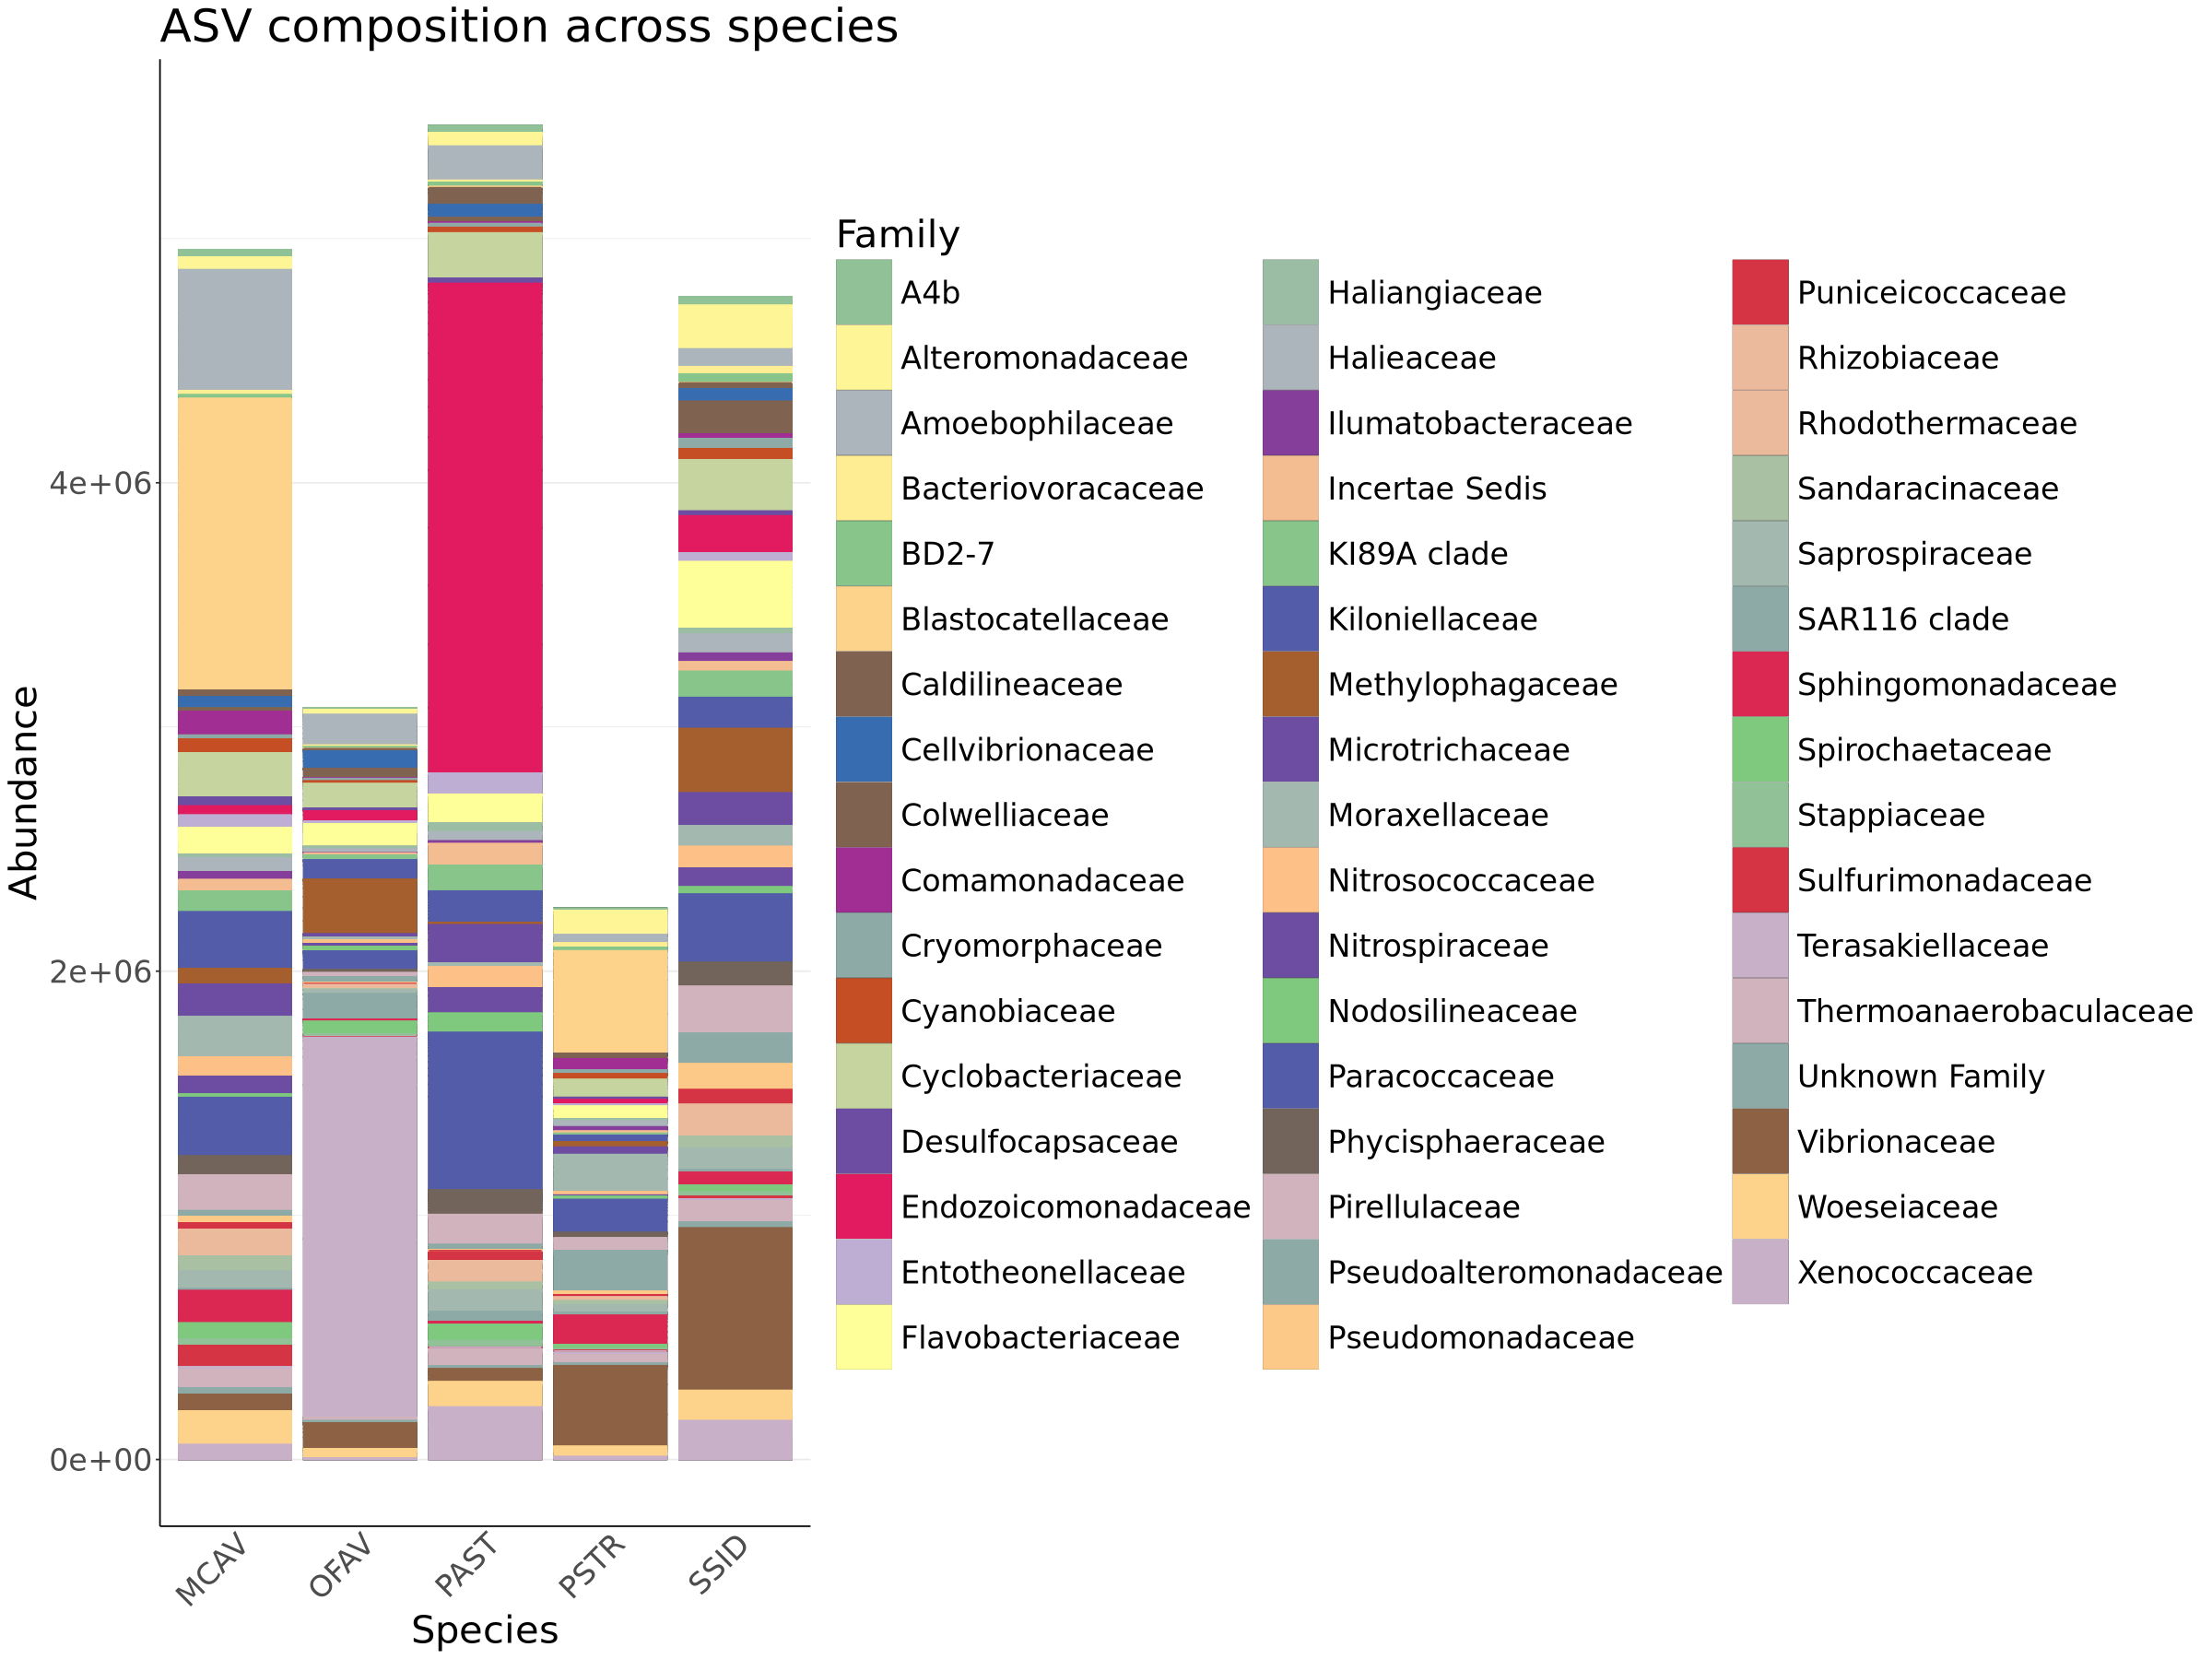

In [49]:
fam <- plot_bar(ps_fam, x="species", fill = "Family") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  labs(title = "ASV composition across species",
       x = "Species",
       y = "Abundance",
       color = "Family") +
  scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 25),
  legend.text = element_text(size = 20),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 25)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
fam

### taxa by species + colony

### past

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


<Guides[1] ggproto object>

colour : <GuideLegend>

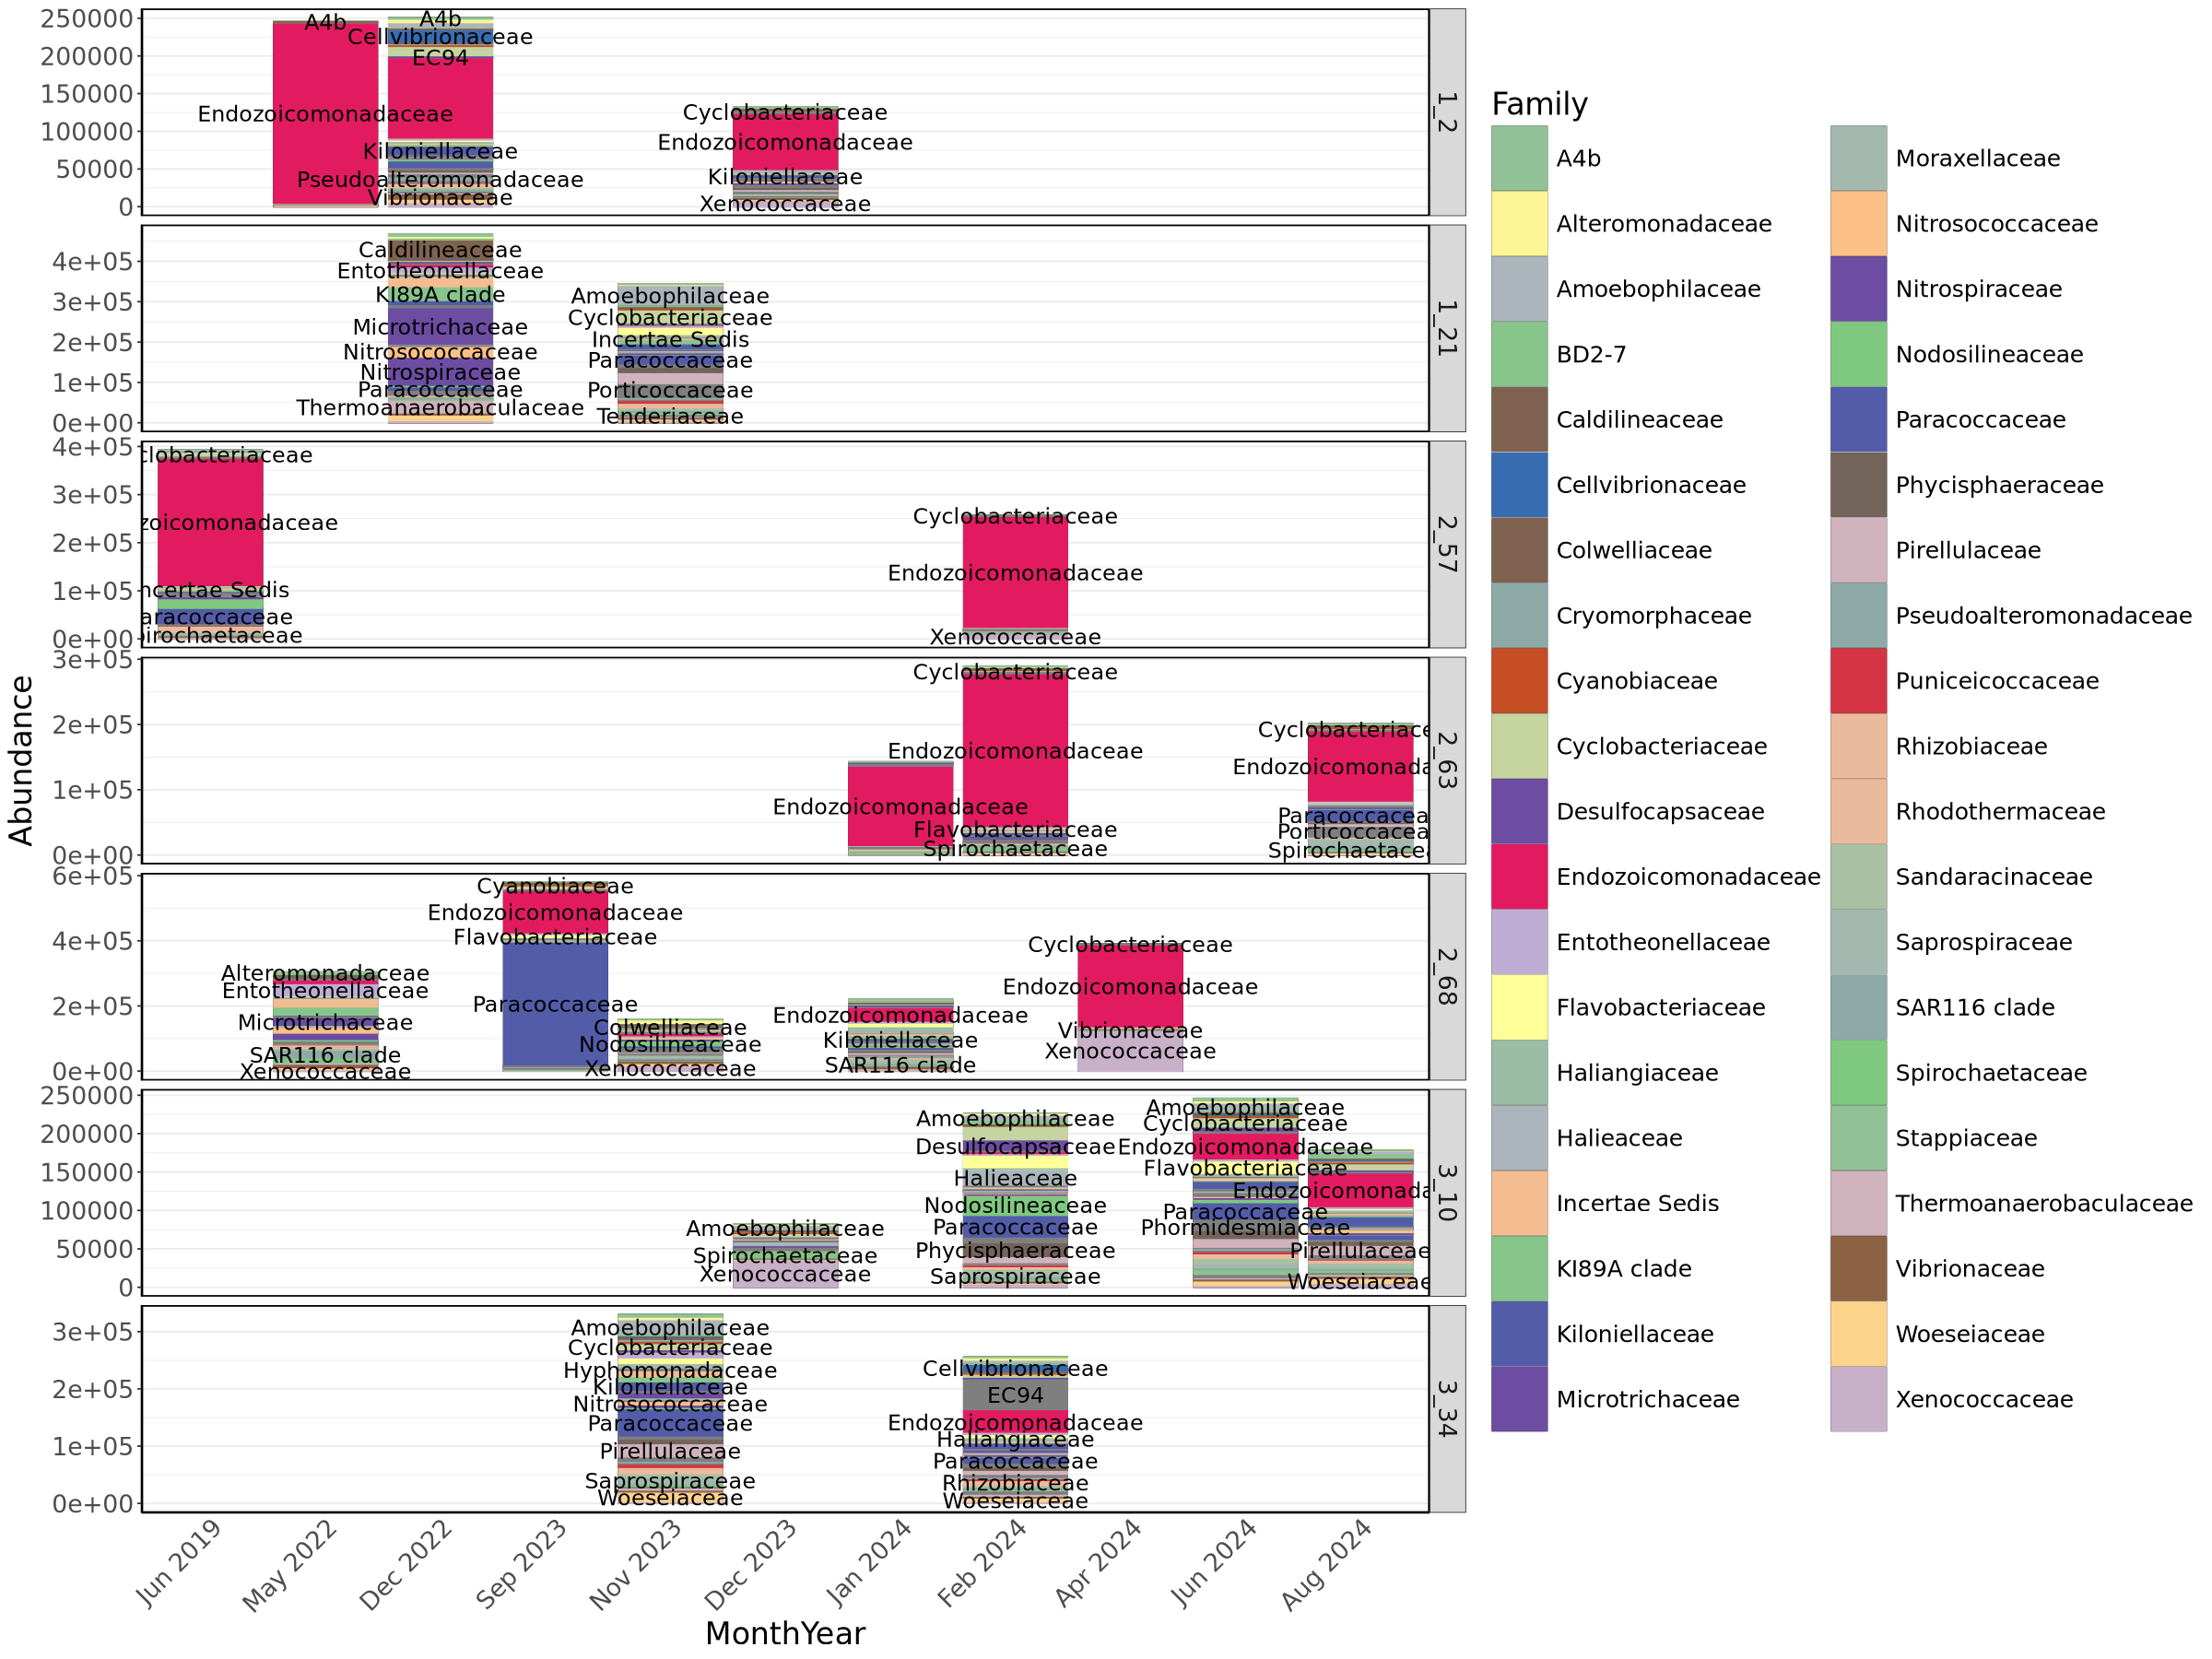

In [50]:
ps_past=tax_glom(ps_past, taxrank= "Family")

top50_past <- names(sort(taxa_sums(ps_past), decreasing=TRUE))[1:50] 
top50_past <- prune_taxa(top50_past, ps_past) 

#plot
past <- plot_bar(top50_past, x="MonthYear", fill = "Family") +
  facet_wrap(colony ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 5, check_overlap = TRUE) +
  scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
past

### pstr

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


<Guides[1] ggproto object>

colour : <GuideLegend>

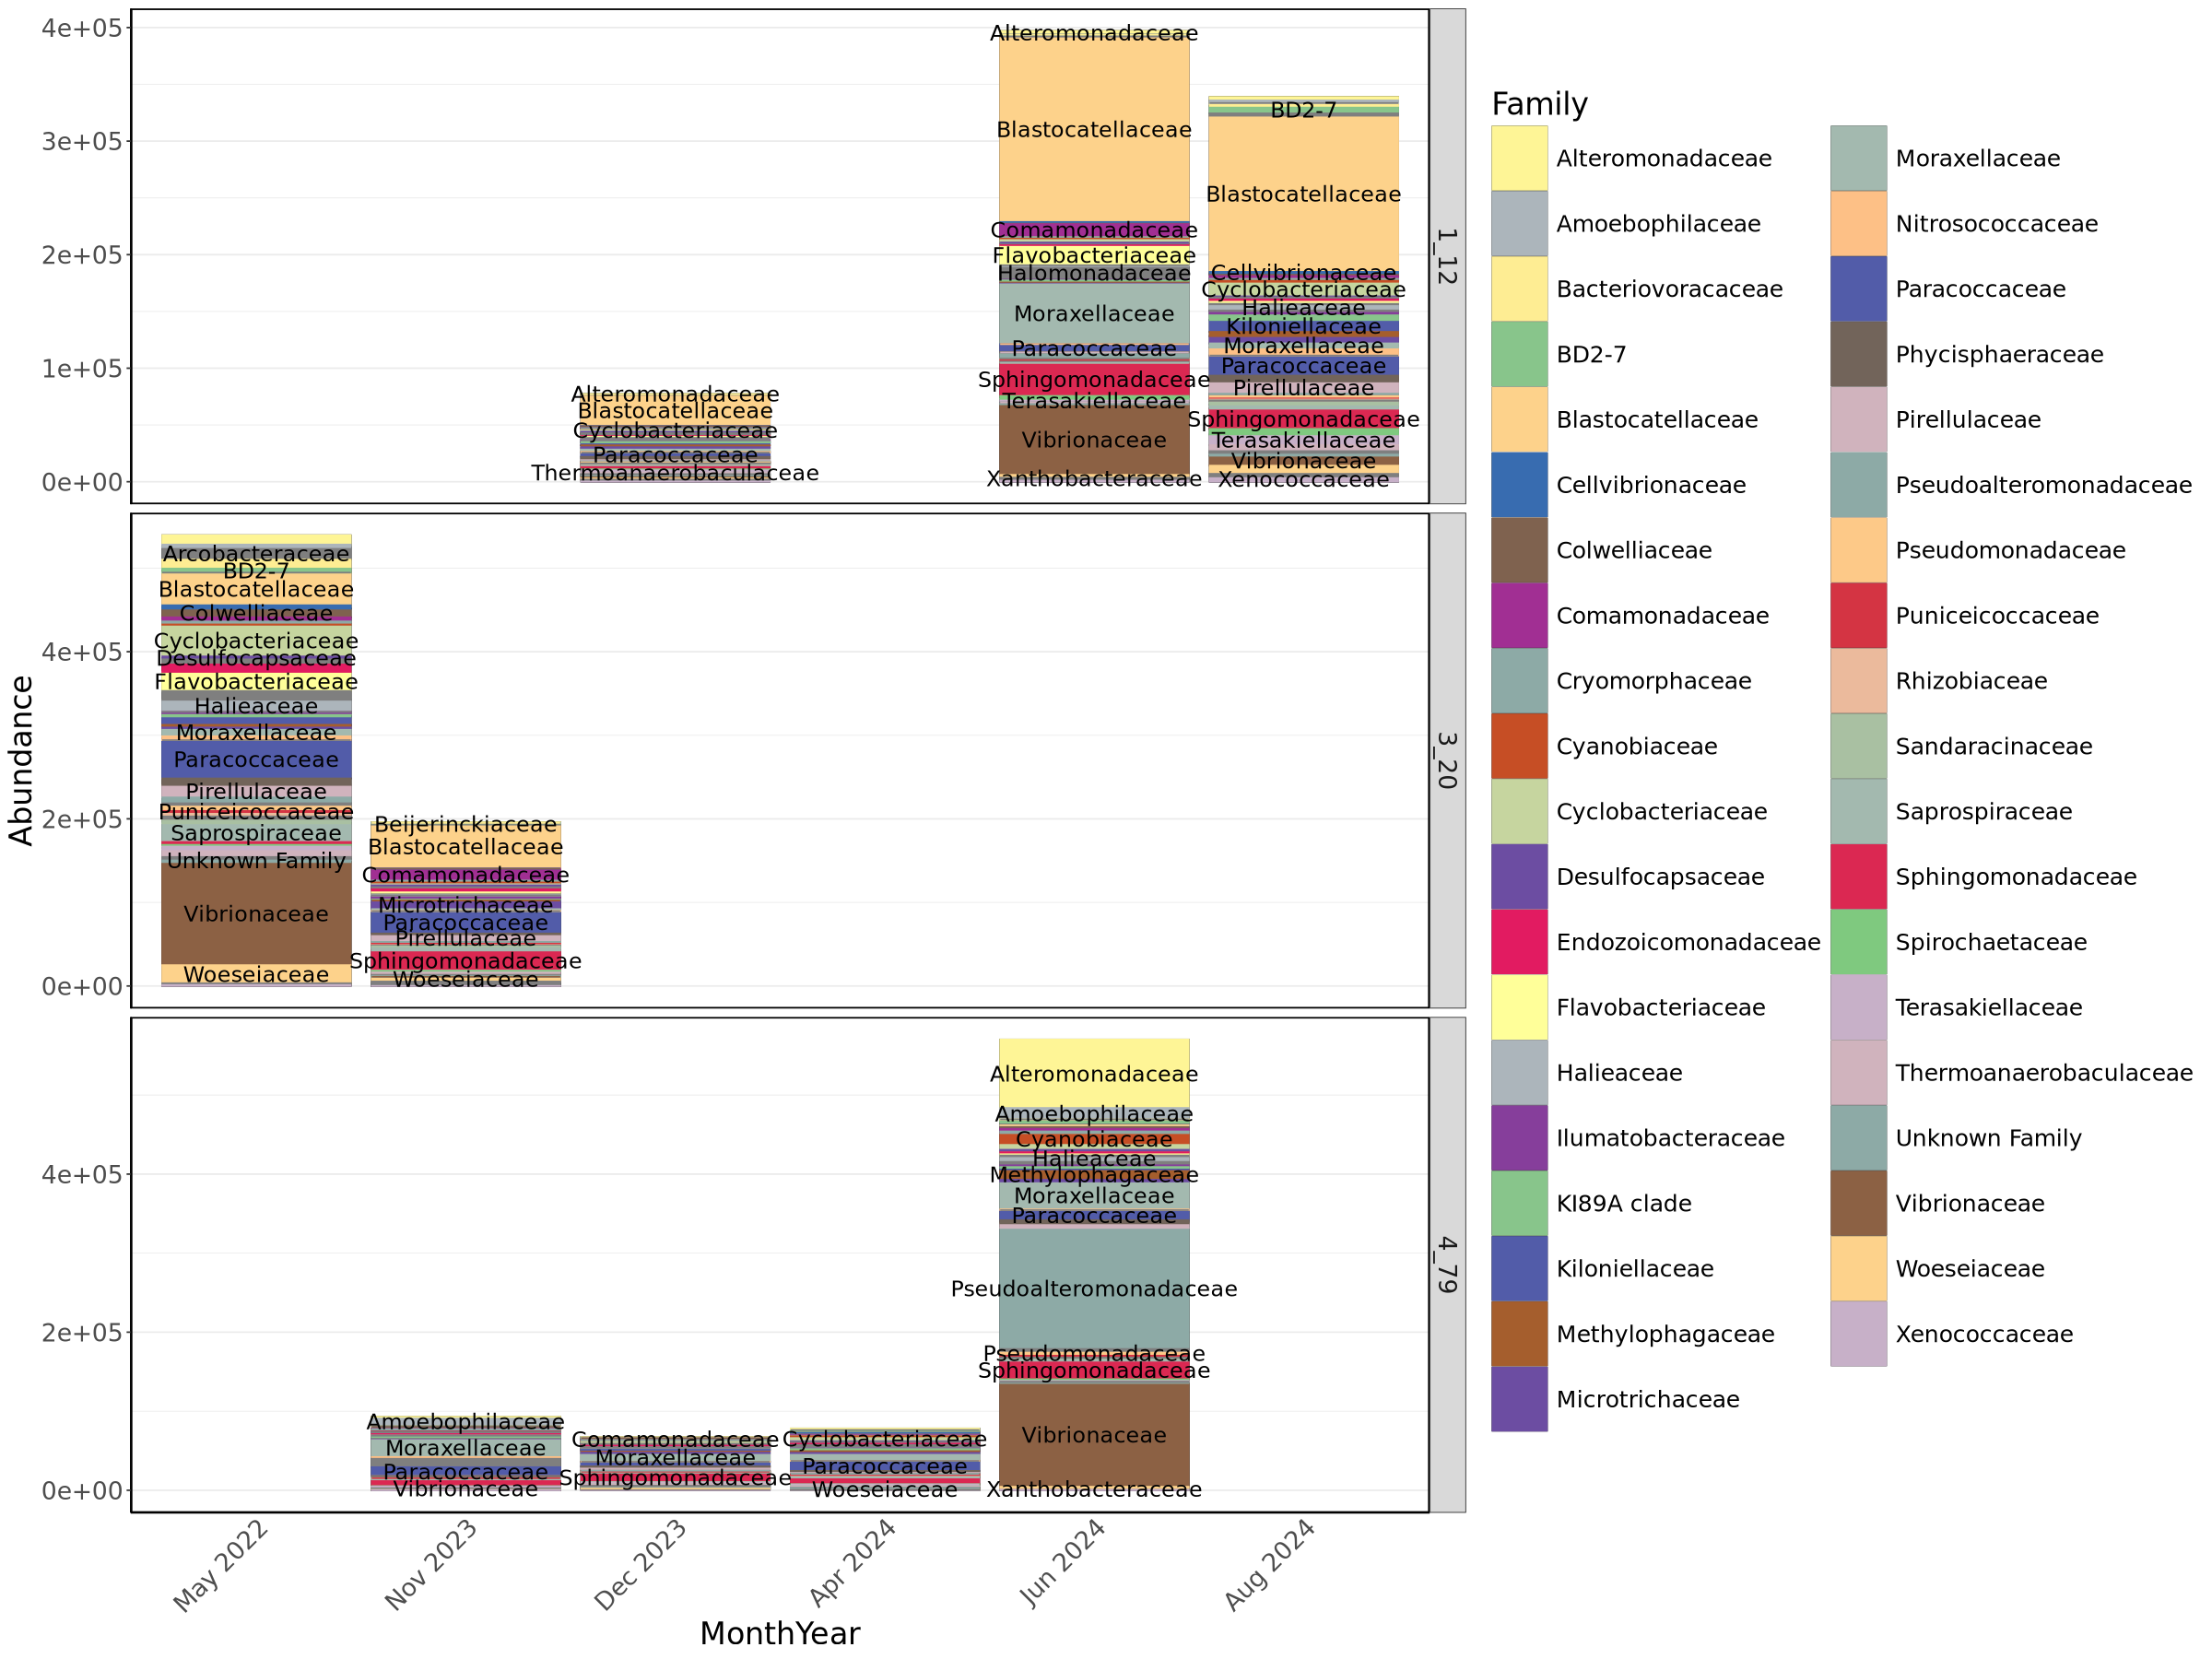

In [51]:
#plot
fam_pstr=tax_glom(ps_pstr, taxrank= "Family")

top50_pstr <- names(sort(taxa_sums(fam_pstr), decreasing=TRUE))[1:50] 
fam_pstr <- prune_taxa(top50_pstr, fam_pstr) 
fam_pstr <- plot_bar(fam_pstr, x="MonthYear", fill="Family") +
   facet_wrap(colony ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 5, check_overlap = TRUE) +
  scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
fam_pstr